<a href="https://colab.research.google.com/github/Ganzadidier/Malaria-Diagnosis-CNN-Transfer-Learning/blob/Master/MobileNet_Malaria_Diagnosis_CNN_Group3_EvenNumber.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning for Malaria Diagnosis
This notebook is inspired by works of (Sivaramakrishnan Rajaraman  et al., 2018) and (Jason Brownlee, 2019). Acknowledge to NIH and Bangalor Hospital who make available this malaria dataset.

Malaria is an infectuous disease caused by parasites that are transmitted to people through the bites of infected female Anopheles mosquitoes.

The Malaria burden with some key figures:
<font color='red'>
* More than 219 million cases
* Over 430 000 deaths in 2017 (Mostly: children & pregnants)
* 80% in 15 countries of Africa & India
  </font>

![MalariaBurd](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/MalariaBurden.png?raw=1)

The malaria diagnosis is performed using blood test:
* Collect patient blood smear
* Microscopic visualisation of the parasit

![MalariaDiag](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/MalariaDiag.png?raw=1)
  
Main issues related to traditional diagnosis:
<font color='#ed7d31'>
* resource-constrained regions
* time needed and delays
* diagnosis accuracy and cost
</font>

The objective of this notebook is to apply modern deep learning techniques to perform medical image analysis for malaria diagnosis.

*This notebook is inspired by works of (Sivaramakrishnan Rajaraman  et al., 2018), (Adrian Rosebrock, 2018) and (Jason Brownlee, 2019)*

## Configuration

In [ ]:
# Use GPU: Please check if the outpout is '/device:GPU:0'
import tensorflow as tf
print(tf.__version__)
tf.test.gpu_device_name()
#from tensorflow.python.client import device_lib
#device_lib.list_local_devices()

## Populating namespaces

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import shutil
import random
import itertools

In [ ]:
# Define the useful paths for data accessibility
ai_project = '.' #"/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis"
cell_images_dir = os.path.join(ai_project,'cell_images')
training_path = os.path.join(ai_project,'train')
testing_path = os.path.join(ai_project,'test')

## Prepare DataSet

### *Download* DataSet

In [ ]:
# Download the data in the allocated google cloud-server. If already down, turn downloadData=False
downloadData = True
if downloadData == True:
  indrive = False
  if indrive == True:
    !wget https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip -P "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis"
    !unzip "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis/cell_images.zip" -d "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis/"
    !ls "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis"
  else: #incloud google server
    !rm -rf cell_images.*
    !wget https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip
    !unzip cell_images.zip >/dev/null 2>&1
    !ls

--2025-10-03 06:18:03--  https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip
Resolving data.lhncbc.nlm.nih.gov (data.lhncbc.nlm.nih.gov)... 3.167.192.56, 3.167.192.111, 3.167.192.60, ...
Connecting to data.lhncbc.nlm.nih.gov (data.lhncbc.nlm.nih.gov)|3.167.192.56|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 353452851 (337M) [application/zip]
Saving to: ‘cell_images.zip’

cell_images.zip     100%[===================>] 337.08M   381MB/s    in 0.9s    

2025-10-03 06:18:04 (381 MB/s) - ‘cell_images.zip’ saved [353452851/353452851]

cell_images  cell_images.zip  sample_data


## Baseline CNN Model
Define a basic ConvNet defined with ConvLayer: Conv2D => MaxPooling2D followed by Flatten => Dense => Dense(output)

![ConvNet](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/ConvNet.png?raw=1)


# 2. Define Project Paths

In [ ]:
BASE_DIR = '/content/cell_images'
DATA_DIR = os.path.join(BASE_DIR) # Corrected path
TRAIN_DIR = os.path.join(BASE_DIR, 'malaria_dataset/train')
TEST_DIR = os.path.join(BASE_DIR, 'malaria_dataset/test')

print(f"Data Directory: {DATA_DIR}")
print(f"Training Directory: {TRAIN_DIR}")
print(f"Testing Directory: {TEST_DIR}")

Data Directory: /content/cell_images
Training Directory: /content/cell_images/malaria_dataset/train
Testing Directory: /content/cell_images/malaria_dataset/test


# 3. Data Preparation



In [ ]:
# This script splits the data into training and testing sets. It only needs to be run once.
def split_data(source_dir, train_dir, test_dir, split_size=0.8):
    if os.path.exists(train_dir):
        print("Dataset directory already exists. Removing and re-splitting.")
        shutil.rmtree(os.path.dirname(train_dir)) # Remove the parent directory 'malaria_dataset'
    print("Creating new dataset directories...")
    os.makedirs(train_dir, exist_ok=True)
    os.makedirs(test_dir, exist_ok=True)
    for category in ['Parasitized', 'Uninfected']:
        os.makedirs(os.path.join(train_dir, category), exist_ok=True)
        os.makedirs(os.path.join(test_dir, category), exist_ok=True)
        category_source_path = os.path.join(source_dir, category)
        images = [f for f in os.listdir(category_source_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        random.shuffle(images)
        split_point = int(len(images) * split_size)
        train_images = images[:split_point]
        test_images = images[split_point:]
        for img in train_images:
            shutil.copy(os.path.join(category_source_path, img), os.path.join(train_dir, category, img))
        for img in test_images:
            shutil.copy(os.path.join(category_source_path, img), os.path.join(test_dir, category, img))
    print("Data splitting complete.")

split_data(DATA_DIR, TRAIN_DIR, TEST_DIR)

# ### Create Data Generators
IMG_WIDTH, IMG_HEIGHT = 128, 128
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Creating new dataset directories...
Data splitting complete.
Found 17638 images belonging to 2 classes.
Found 4408 images belonging to 2 classes.
Found 5512 images belonging to 2 classes.


# 3. Evaluation Framework

In [10]:
def evaluate_model(model, history, test_generator):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    # Save the learning curves
    plt.savefig('learning_curves.png')
    plt.show()

    Y_pred = model.predict(test_generator)
    y_pred = np.round(Y_pred)
    y_true = test_generator.classes
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=['Parasitized', 'Uninfected']))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 6))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(2)
    plt.xticks(tick_marks, ['Parasitized', 'Uninfected'], rotation=45)
    plt.yticks(tick_marks, ['Parasitized', 'Uninfected'])
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], 'd'), horizontalalignment="center", color="white" if cm[i, j] > thresh else "black")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    # Save the confusion matrix
    plt.savefig('confusion_matrix.png')
    plt.show()

    fpr, tpr, _ = roc_curve(y_true, Y_pred)
    roc_auc = auc(fpr, tpr)
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:0.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    # Save the ROC curve
    plt.savefig('roc_curve.png')
    plt.show()


# 4. MobileNetV2 Model Experiment

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 2,914,369 (11.12 MB)

 Trainable params: 656,385 (2.50 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/10
552/552 ━━━━━━━━━━━━━━━━━━━━ 149s 237ms/step - accuracy: 0.7869 - loss: 0.4517 - val_accuracy: 0.8825 - val_loss: 0.2972
Epoch 2/10
552/552 ━━━━━━━━━━━━━━━━━━━━ 113s 205ms/step - accuracy: 0.8713 - loss: 0.3064 - val_accuracy: 0.8852 - val_loss: 0.2964
Epoch 3/10
552/552 ━━━━━━━━━━━━━━━━━━━━ 114s 206ms/step - accuracy: 0.8851 - loss: 0.2921 - val_accuracy: 0.8959 - val_loss: 0.2723
Epoch 4/10
552/552 ━━━━━━━━━━━━━━━━━━━━ 142s 206ms/step - accuracy: 0.8904 - loss: 0.2751 - val_accuracy: 0.8956 - val_loss: 0.2811
Epoch 5/10
552/552 ━━━━━━━━━━━━━━━━━━━━ 115s 209ms/step - accuracy: 0.8989 - loss: 0.2670 - val_accuracy: 0.8902 - val_loss: 0.2785
Epoch 6/10
552/552 ━━━━━━━━━━━━━━━━━━━━ 115s 208ms/step - accuracy: 0.9022 - loss: 0.2552 - val_accuracy: 0.8968 - val_loss: 0.2563
Epoch 7/10
552/552 ━━━━━━━━━━━━━━━━━━━━ 114s 206ms/step - accuracy: 0.8993 - loss: 0.2603 - val_accuracy: 0.9018 - val_loss: 0.2641
Epoch 8/10
552/552 ━━━━━━━━━━━━━━━━━━━━ 113s 205ms/step - accuracy: 0.8988 -

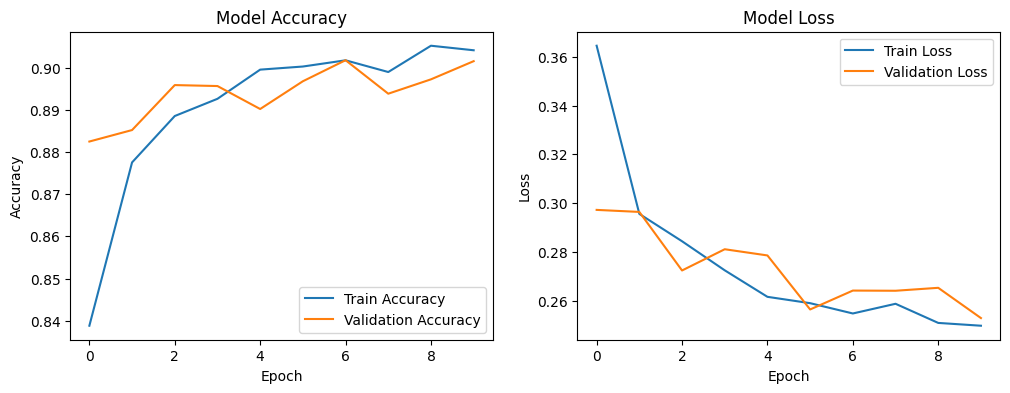

173/173 ━━━━━━━━━━━━━━━━━━━━ 16s 65ms/step

Classification Report:
              precision    recall  f1-score   support

 Parasitized       0.96      0.81      0.88      2756
  Uninfected       0.84      0.97      0.90      2756

    accuracy                           0.89      5512
   macro avg       0.90      0.89      0.89      5512
weighted avg       0.90      0.89      0.89      5512



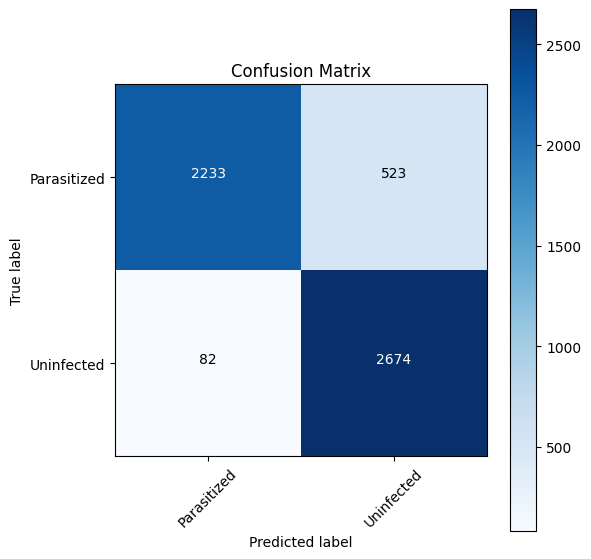

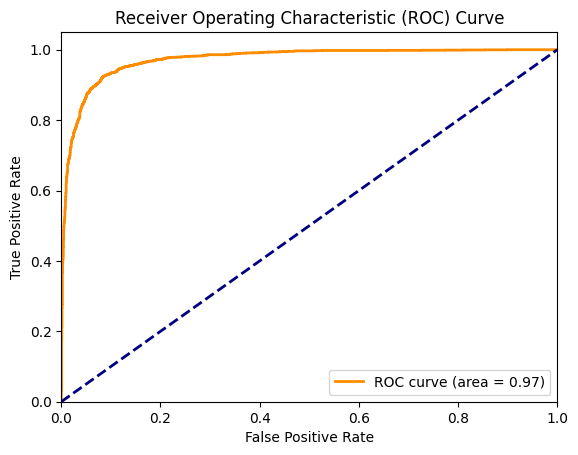

Model saved to malaria_mobilenet_model.h5


In [9]:
def create_mobilenet_model(input_shape=(IMG_WIDTH, IMG_HEIGHT, 3)):
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False
    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    predictions = Dense(1, activation='sigmoid')(x)
    model = Model(inputs=base_model.input, outputs=predictions)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# 1. Create the model
mobilenet_model = create_mobilenet_model()
mobilenet_model.summary()

# 2. Train the model
history_mobilenet = mobilenet_model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)

# 3. Evaluate the model
evaluate_model(mobilenet_model, history_mobilenet, test_generator)

# Save the trained model
mobilenet_model.save('malaria_mobilenet_model.h5')
print("Model saved to malaria_mobilenet_model.h5")


# 5. MobileNetV2 Model Experiment 2

Number of layers in the model:  158


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 2,914,369 (11.12 MB)

 Trainable params: 2,400,705 (9.16 MB)

 Non-trainable params: 513,664 (1.96 MB)

Epoch 1/5
552/552 ━━━━━━━━━━━━━━━━━━━━ 153s 238ms/step - accuracy: 0.8611 - loss: 0.3411 - val_accuracy: 0.8283 - val_loss: 0.5318
Epoch 2/5
552/552 ━━━━━━━━━━━━━━━━━━━━ 115s 208ms/step - accuracy: 0.9093 - loss: 0.2485 - val_accuracy: 0.8870 - val_loss: 0.3326
Epoch 3/5
552/552 ━━━━━━━━━━━━━━━━━━━━ 114s 206ms/step - accuracy: 0.9187 - loss: 0.2178 - val_accuracy: 0.9090 - val_loss: 0.2589
Epoch 4/5
552/552 ━━━━━━━━━━━━━━━━━━━━ 115s 208ms/step - accuracy: 0.9180 - loss: 0.2140 - val_accuracy: 0.9161 - val_loss: 0.2351
Epoch 5/5
552/552 ━━━━━━━━━━━━━━━━━━━━ 117s 211ms/step - accuracy: 0.9292 - loss: 0.1973 - val_accuracy: 0.9256 - val_loss: 0.2088


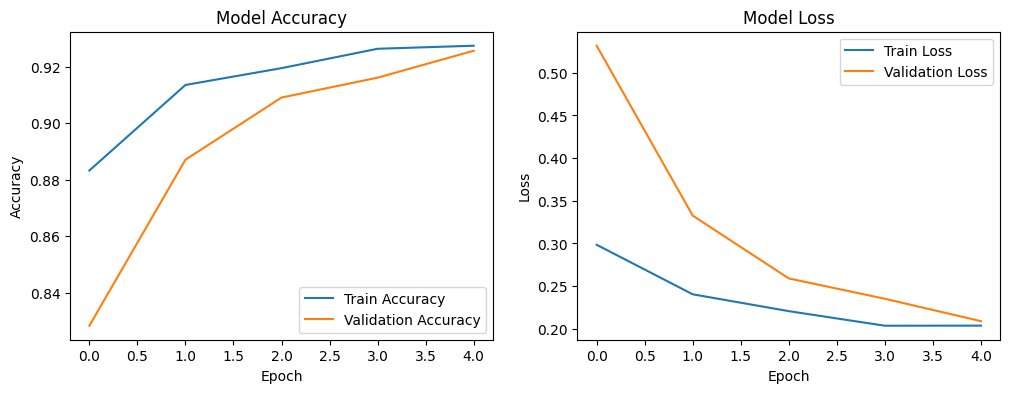

173/173 ━━━━━━━━━━━━━━━━━━━━ 16s 67ms/step

Classification Report:
              precision    recall  f1-score   support

 Parasitized       0.97      0.92      0.94      2756
  Uninfected       0.92      0.97      0.95      2756

    accuracy                           0.94      5512
   macro avg       0.95      0.94      0.94      5512
weighted avg       0.95      0.94      0.94      5512



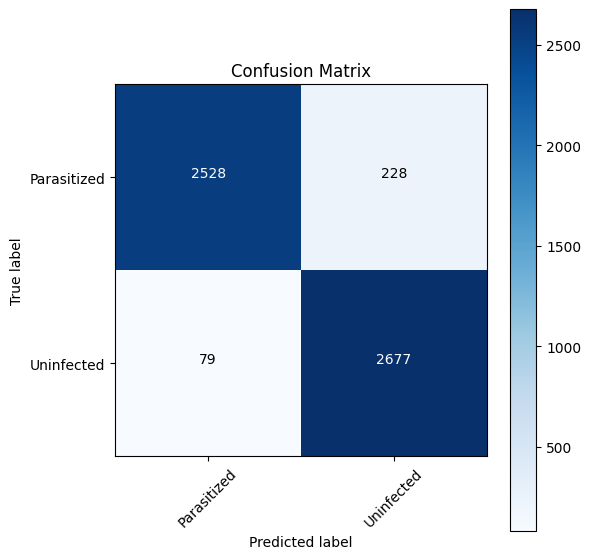

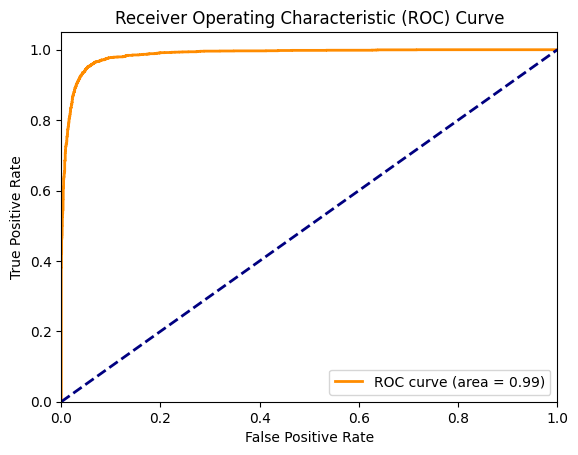

Fine-tuned model saved to malaria_mobilenet_model_tuned.h5


In [17]:
# Fine-tune the MobileNetV2 model

# Unfreeze some layers of the model
# It's common practice to unfreeze layers closer to the output

# Access all layers of the model
all_layers = mobilenet_model.layers

# Let's take a look to see how many layers are in the model
print("Number of layers in the model: ", len(all_layers))

# Fine-tune this many layers from the end of the model
fine_tune_from_layer = 50 # You can adjust this number

# Unfreeze the layers from `fine_tune_from_layer` to the end
# Start from (length of all_layers - fine_tune_from_layer)
for layer in all_layers[len(all_layers) - fine_tune_from_layer:]:
    layer.trainable = True

# Freeze layers before the fine-tuning point (optional, they should be frozen from initial setup)
for layer in all_layers[:len(all_layers) - fine_tune_from_layer]:
    layer.trainable = False


# Recompile the model with a lower learning rate
mobilenet_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001), # Lower learning rate for fine-tuning
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

mobilenet_model.summary()

# Train the model again with fine-tuning
# Use fewer epochs for fine-tuning to avoid overfitting
history_mobilenet_tuned = mobilenet_model.fit(
    train_generator,
    epochs=5, # Reduced epochs for fine-tuning
    validation_data=validation_generator
)

# Evaluate the fine-tuned model
evaluate_model(mobilenet_model, history_mobilenet_tuned, test_generator)

# Save the fine-tuned model
mobilenet_model.save('malaria_mobilenet_model_tuned.h5')
print("Fine-tuned model saved to malaria_mobilenet_model_tuned.h5")